In [102]:
import datetime

import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_log_error
from xgboost import XGBRegressor
import os 
import matplotlib.pyplot as plt

In [103]:
os.getcwd()

'/teamspace/studios/this_studio/notebooks'

In [104]:
# Load data
train = pd.read_csv("../data/raw/train.csv")
test = pd.read_csv("../data/raw/test.csv")
stores = pd.read_csv("../data/raw/stores.csv")
oil = pd.read_csv("../data/raw/oil.csv")
holidays = pd.read_csv("../data/raw/holidays_events.csv")


In [105]:
train.shape

(3000888, 6)

In [106]:
train.head()

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


In [107]:
#Numero de tiendas
train['store_nbr'].nunique()

54

In [108]:
#Numero de familias de productos 
train['family'].nunique()

33

In [109]:
#Convertir la columna de fecha a formato datetime 
train['date'] = pd.to_datetime(train['date'])

In [110]:
# Establecer los índices (Equivalente a indexes=["store_nbr", "family"])
# Ponemos la fecha también en el índice para facilitar gráficas y filtros temporales
train = train.set_index(['store_nbr', 'family', 'date'])

In [111]:
train.head()

id  sales  onpromotion
store_nbr family     date                              
1         AUTOMOTIVE 2013-01-01   0    0.0            0
          BABY CARE  2013-01-01   1    0.0            0
          BEAUTY     2013-01-01   2    0.0            0
          BEVERAGES  2013-01-01   3    0.0            0
          BOOKS      2013-01-01   4    0.0            0

In [112]:
train = train.sort_index()

In [113]:
train.head()

id  sales  onpromotion
store_nbr family     date                                
1         AUTOMOTIVE 2013-01-01     0    0.0            0
                     2013-01-02  1782    2.0            0
                     2013-01-03  3564    3.0            0
                     2013-01-04  5346    3.0            0
                     2013-01-05  7128    5.0            0

Vamos a analizar las series temporales de cada tienda

In [114]:
def graficar_series(store_id, n):

    data_store = train.loc[store_id] # Esto nos deja solo con ['family', 'date']

    # Obtenemos las familias de esa tienda
    families = data_store.index.get_level_values('family').unique()

    # n no puede ser mayor al numero de familias
    # Ajustamos n para que no supere la cantidad de familias reales
    n = min(n, len(families))

    # Defino la cantidad de tiendas que quiero ver forzando a que sea múltiplo de 4
    if (n%4) != 0:
        n = (n - n%4) + 4

    ini = 0
    while ini < n:
        fin = min(ini + 4, n) # Asegura que el último grupo no se pase
        
        # CREAR LA FIGURA DENTRO DEL BUCLE para que cada grupo de 4 sea un cuadro nuevo
        fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(10, 12), sharex=True)
        
        # Usamos slicing [ini:fin] para sacar el grupo de 4 actual
        for i, family in enumerate(families[ini:fin]):
            subset = data_store.loc[family]
            axes[i].plot(subset.index, subset['sales'])
            axes[i].set_title(f"Store {store_id} - Family: {family}")
            
        plt.tight_layout()
        plt.show() # Muestra las 4 actuales y limpia para las siguientes
        
        ini = fin

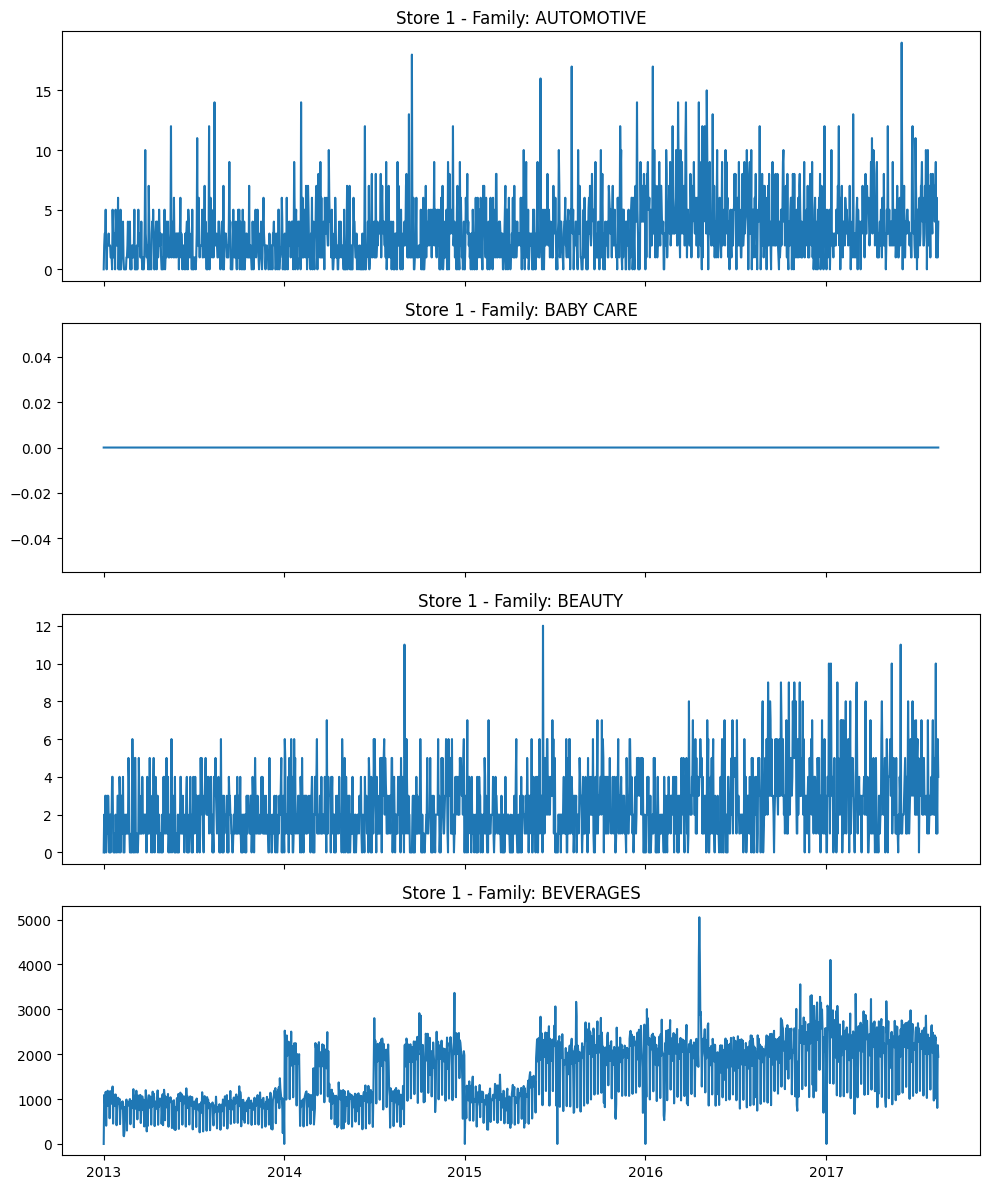

In [115]:
graficar_series(1,4)

In [116]:
train_ = train.reset_index()

Datos de precio del petroleo

In [117]:
#oil
oil['date'] = pd.to_datetime(oil['date'])

oil = (
    oil.set_index('date')
    .resample('D')
    .ffill()
    .reset_index()
)

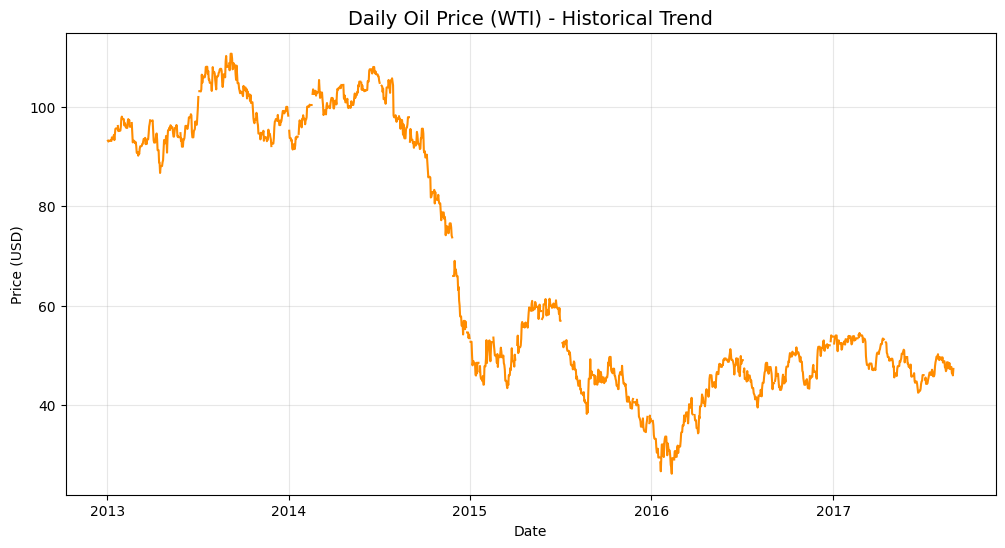

In [118]:
plt.figure(figsize=(12, 6))
plt.plot(oil['date'], oil['dcoilwtico'], color='darkorange', linewidth=1.5)

# Adding details
plt.title('Daily Oil Price (WTI) - Historical Trend', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.grid(True, alpha=0.3)

plt.show()

Datos de dataset de días especiales y de trabajo

In [119]:
holidays_filtered = holidays[
    (~holidays['transferred']) &
    (holidays['locale'] == 'National') &
    (holidays['type'] != 'Work Day')
]

In [120]:
holidays_filtered['date'] = pd.to_datetime(holidays_filtered['date'])

In [121]:
holidays_filtered.head()

,date,type,locale,locale_name,description,transferred
14,2012-08-10,Holiday,National,Ecuador,Primer Grito de Independencia,False
20,2012-10-12,Transfer,National,Ecuador,Traslado Independencia de Guayaquil,False
21,2012-11-02,Holiday,National,Ecuador,Dia de Difuntos,False
22,2012-11-03,Holiday,National,Ecuador,Independencia de Cuenca,False
31,2012-12-21,Additional,National,Ecuador,Navidad-4,False


In [122]:
work_days = holidays[holidays['type'] == 'Work Day']

In [123]:
work_days['date'] = pd.to_datetime(work_days['date'])

In [124]:
work_days.head()

,date,type,locale,locale_name,description,transferred
42,2013-01-05,Work Day,National,Ecuador,Recupero puente Navidad,False
43,2013-01-12,Work Day,National,Ecuador,Recupero puente primer dia del ano,False
149,2014-12-20,Work Day,National,Ecuador,Recupero Puente Navidad,False
161,2015-01-10,Work Day,National,Ecuador,Recupero Puente Primer dia del ano,False
283,2016-11-12,Work Day,National,Ecuador,Recupero Puente Dia de Difuntos,False


Feature Engineering

In [125]:
def create_features(df, oil, holiday_dates, workday_dates):

    df = df.copy()

    # ordenar UNA sola vez
    df = df.sort_values(["store_nbr", "family", "date"])

    # -------------------------
    # OIL FEATURE
    # -------------------------

    df = df.merge(
        oil[["date", "dcoilwtico"]],
        on="date",
        how="left"
    )

    df["oil_price"] = df["dcoilwtico"].ffill()

    df.drop(columns="dcoilwtico", inplace=True)

    # -------------------------
    # HOLIDAY FEATURES
    # -------------------------

    df["is_holiday"] = df["date"].isin(holiday_dates).astype("int8")

    df["is_workday"] = df["date"].isin(workday_dates).astype("int8")

    # -------------------------
    # GROUPBY (solo una vez)
    # -------------------------

    group = df.groupby(["store_nbr", "family"])

    # -------------------------
    # LAGS
    # -------------------------

    df["lag_1d"] = group["sales"].shift(1)
    df["lag_1w"] = group["sales"].shift(7)
    df["lag_1m"] = group["sales"].shift(28)
    df["lag_1y"] = group["sales"].shift(364)

    # -------------------------
    # ROLLING MEANS
    # -------------------------

    df["avg_1w"] = group["sales"].rolling(7).mean().reset_index(level=[0,1], drop=True)

    df["avg_1m"] = group["sales"].rolling(28).mean().reset_index(level=[0,1], drop=True)

    df["avg_1y"] = group["sales"].rolling(364).mean().reset_index(level=[0,1], drop=True)

    # -------------------------
    # ROLLING STD
    # -------------------------

    df["std_1w"] = group["sales"].rolling(7).std().reset_index(level=[0,1], drop=True)

    df["std_1m"] = group["sales"].rolling(28).std().reset_index(level=[0,1], drop=True)

    df["std_1y"] = group["sales"].rolling(364).std().reset_index(level=[0,1], drop=True)

    # -------------------------
    # STORE LEVEL FEATURE
    # -------------------------

    store_group = df.groupby("store_nbr")["sales"]

    df["store_avg_1w"] = (
        store_group
        .rolling(7)
        .mean()
        .reset_index(level=0, drop=True)
    )

    # -------------------------
    # CALENDAR FEATURES
    # -------------------------

    date = df["date"]

    df["day_of_week"] = date.dt.dayofweek.astype("int8")
    df['day_of_month'] = df['date'].dt.day
    df["month"] = date.dt.month.astype("int8")
    df["year"] = date.dt.year.astype("int16")

    # -------------------------
    # MULTIINDEX FINAL
    # -------------------------

    df = df.set_index(["store_nbr", "family", "date"]).sort_index()

    return df

In [126]:
holiday_dates = set(pd.to_datetime(holidays_filtered["date"]))
workday_dates = set(pd.to_datetime(work_days["date"]))

In [127]:
train_features = create_features(train_, oil, holiday_dates, workday_dates)

In [128]:
train_features.head()

id  sales  onpromotion  oil_price  \
store_nbr family     date                                              
1         AUTOMOTIVE 2013-01-01     0    0.0            0        NaN   
                     2013-01-02  1782    2.0            0      93.14   
                     2013-01-03  3564    3.0            0      92.97   
                     2013-01-04  5346    3.0            0      93.12   
                     2013-01-05  7128    5.0            0      93.12   

                                 is_holiday  is_workday  lag_1d  lag_1w  \
store_nbr family     date                                                 
1         AUTOMOTIVE 2013-01-01           1           0     NaN     NaN   
                     2013-01-02           0           0     0.0     NaN   
                     2013-01-03           0           0     2.0     NaN   
                     2013-01-04           0           0     3.0     NaN   
                     2013-01-05           0           1     3.0     NaN   

                                 lag_1m  lag_1y  ...  avg_1m  avg_1y  std_1w  \
store_nbr family     date                        ...                           
1         AUTOMOTIVE 2013-01-01     NaN     NaN  ...     NaN     NaN     NaN   
                     2013-01-02     NaN     NaN  ...     NaN     NaN     NaN   
                     2013-01-03     NaN     NaN  ...     NaN     NaN     NaN   
                     2013-01-04     NaN     NaN  ...     NaN     NaN     NaN   
                     2013-01-05     NaN     NaN  ...     NaN     NaN     NaN   

                                 std_1m  std_1y  store_avg_1w  day_of_week  \
store_nbr family     date                                                    
1         AUTOMOTIVE 2013-01-01     NaN     NaN           NaN            1   
                     2013-01-02     NaN     NaN           NaN            2   
                     2013-01-03     NaN     NaN           NaN            3   
                     2013-01-04     NaN     NaN           NaN            4   
                     2013-01-05     NaN     NaN           NaN            5   

                                 day_of_month  month  year  
store_nbr family     date                                   
1         AUTOMOTIVE 2013-01-01             1      1  2013  
                     2013-01-02             2      1  2013  
                     2013-01-03             3      1  2013  
                     2013-01-04             4      1  2013  
                     2013-01-05             5      1  2013  

[5 rows x 21 columns]

In [129]:
train_features.shape

(3000888, 21)

In [130]:
train_features.isna().sum().sort_values(ascending=False)

lag_1y          648648
avg_1y          646866
std_1y          646866
lag_1m           49896
std_1m           48114
avg_1m           48114
lag_1w           12474
std_1w           10692
avg_1w           10692
lag_1d            1782
store_avg_1w       324
oil_price            1
id                   0
is_holiday           0
onpromotion          0
sales                0
is_workday           0
day_of_week          0
day_of_month         0
month                0
year                 0
dtype: int64

In [131]:
train_features = train_features.dropna()

In [132]:
train_features.shape

(2352240, 21)

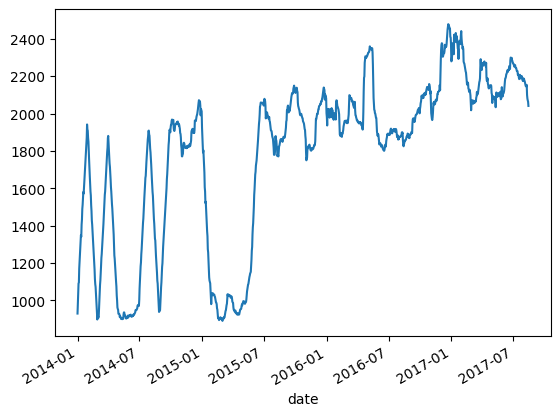

In [133]:
subset = train_features.loc[(1,'BEVERAGES')].avg_1m.plot()

Train

In [134]:
def prepare_features(df):

    X = df.copy()

    # Eliminamos el target
    X = X.drop(columns=['sales'])

    # Convertimos family en categórica
    X['family'] = X['family'].astype('category')

    return X

In [135]:
def prepare_target(df):

    y = df['sales']

    return y

In [136]:
df = train_features.reset_index()

X = prepare_features(df)
y = prepare_target(df)

In [137]:
X = X.drop(columns=['date'])

In [138]:
print(X.shape)
print(y.shape)

X.head()

(2352240, 22)
(2352240,)


,store_nbr,family,id,onpromotion,oil_price,is_holiday,is_workday,lag_1d,lag_1w,lag_1m,...,avg_1m,avg_1y,std_1w,std_1m,std_1y,store_avg_1w,day_of_week,day_of_month,month,year
0,1,AUTOMOTIVE,648648,0,98.17,1,0,2.0,1.0,2.0,...,1.857143,2.145604,2.193063,1.757825,2.028233,2.142857,2,1,1,2014
1,1,AUTOMOTIVE,650430,0,95.14,0,0,0.0,2.0,1.0,...,1.928571,2.148352,2.214670,1.762334,2.028712,2.285714,3,2,1,2014
2,1,AUTOMOTIVE,652212,0,93.66,0,0,3.0,6.0,0.0,...,1.928571,2.140110,1.618347,1.762334,2.031335,1.428571,4,3,1,2014
3,1,AUTOMOTIVE,653994,0,93.66,0,0,0.0,4.0,2.0,...,1.857143,2.131868,1.214986,1.799471,2.033921,0.857143,5,4,1,2014
4,1,AUTOMOTIVE,655776,0,93.66,0,0,0.0,0.0,2.0,...,1.821429,2.120879,1.154701,1.806441,2.029182,1.000000,6,5,1,2014


In [139]:
X.dtypes

store_nbr          int64
family          category
id                 int64
onpromotion        int64
oil_price        float64
is_holiday          int8
is_workday          int8
lag_1d           float64
lag_1w           float64
lag_1m           float64
lag_1y           float64
avg_1w           float64
avg_1m           float64
avg_1y           float64
std_1w           float64
std_1m           float64
std_1y           float64
store_avg_1w     float64
day_of_week         int8
day_of_month       int32
month               int8
year               int16
dtype: object

In [140]:
X.isna().sum().sort_values(ascending=False)

store_nbr       0
family          0
id              0
onpromotion     0
oil_price       0
is_holiday      0
is_workday      0
lag_1d          0
lag_1w          0
lag_1m          0
lag_1y          0
avg_1w          0
avg_1m          0
avg_1y          0
std_1w          0
std_1m          0
std_1y          0
store_avg_1w    0
day_of_week     0
day_of_month    0
month           0
year            0
dtype: int64

In [141]:
from xgboost import XGBRegressor

model = XGBRegressor(
    tree_method="hist",
    enable_categorical=True,
    objective="count:poisson"
)

model.fit(X, y)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'count:poisson'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fro

In [142]:
preds = model.predict(X)

In [143]:
from sklearn.metrics import mean_squared_log_error
import numpy as np

rmsle = np.sqrt(mean_squared_log_error(y, preds))

print(rmsle)

0.4527667764959049


In [144]:
importance = model.get_booster().get_score(importance_type='gain')
sorted(importance.items(), key=lambda item: item[1], reverse=True)

[('avg_1w', 8772895.0),
 ('lag_1w', 253733.703125),
 ('lag_1m', 123066.8125),
 ('lag_1d', 80081.171875),
 ('month', 48140.6875),
 ('day_of_week', 37069.88671875),
 ('is_holiday', 27355.669921875),
 ('onpromotion', 25807.61328125),
 ('day_of_month', 24285.1171875),
 ('lag_1y', 24013.98828125),
 ('std_1w', 21743.521484375),
 ('std_1y', 16002.5546875),
 ('id', 14851.9072265625),
 ('oil_price', 10123.8671875),
 ('family', 9688.072265625),
 ('store_nbr', 8884.8857421875),
 ('avg_1m', 6821.0615234375),
 ('is_workday', 6177.80859375),
 ('std_1m', 6166.71826171875),
 ('avg_1y', 4262.1787109375)]

Predict

In [145]:
test["date"] = pd.to_datetime(test["date"])

In [146]:
test_dates = sorted(test["date"].unique())

In [147]:
curr_data = train_features.reset_index().copy()

In [148]:
predictions = []